# FoodSeg103 Dataset Rebalancing Notebook

Create a new dataset version by:
1. Removing low-frequency classes (configurable threshold).
2. Merging semantically similar classes (custom mapping).

This notebook is designed to mitigate class imbalance before training.

## Workflow

1. Configure thresholds and merge rules.
2. Scan annotation files and compute class statistics.
3. Suggest candidate pairs from class-name similarity + co-occurrence.
4. Validate merge groups with GLCM texture cosine similarity (threshold = 0.85 by default).
5. Build a class remapping plan.
6. Export a new filtered and merged dataset.

In [1]:
import json
import shutil
from collections import Counter, defaultdict
from difflib import SequenceMatcher
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm

# =========================
# User Configuration
# =========================
CANDIDATE_ROOTS = [
    Path("./foodseg103"),
    Path("./test/foodseg103"),
    Path("../foodseg103"),
]

OUTPUT_ROOT = Path("./foodseg103_rebalanced")
SPLITS = ["train", "test"]
IMAGE_EXTS = (".jpg", ".jpeg", ".png")

# Keep class only if merged class satisfies both thresholds.
MIN_IMAGES_PER_CLASS = 0
MIN_OBJECTS_PER_CLASS = 0

# Optional explicit overrides.
FORCE_KEEP_CLASSES = set([
    # "rice",
])
FORCE_DROP_CLASSES = set([
    # "unknown",
])

# Mapping from old class name to new merged class name.
# Edit this to merge similar classes.
MERGE_MAP = {
    # "chicken duck": "poultry",
    # "duck": "poultry",
    # "fried rice": "rice",
    "king oyster mushroom": "mushroom",
    "oyster mushroom": "mushroom",
    "enoki mushroom": "mushroom",
    "white button mushroom": "mushroom",
    "shiitake": "mushroom",

    "green beans": "beans_and_peas",
    "french beans": "beans_and_peas",
    "snow peas": "beans_and_peas",
    "bean sprouts": "beans_and_peas",
    "soy": "beans_and_peas",
    "red beans": "beans_and_peas",
    "okra": "beans_and_peas",

    "peanut": "nut",
    "almond": "nut",
    "cashew": "nut",
    "walnut": "nut",

    "cake": "desserts",
    "biscuit": "desserts",
    "pudding": "desserts",
    "egg tart": "desserts",
    "candy": "desserts",
    "chocolate": "desserts",
    "popcorn": "desserts",

    "lemon": "citrus",
    "orange": "citrus",

    "spring onion": "alliums_and_garlic",
    "onion": "alliums_and_garlic",
    "garlic": "alliums_and_garlic",
    "ginger": "alliums_and_garlic",

    "bamboo shoots": "other ingredients",
    "date": "other ingredients",

    "kelp": "seaweed",
    "seaweed": "seaweed",

    "cabbage": "leafy_greens",
    "rape": "leafy_greens",
    "lettuce": "leafy_greens",
}

# Exclude noisy auto-similarity pairs from merge suggestions (order-insensitive).
EXCLUDED_SIMILARITY_PAIRS = {
}

# Optional: only suggest similarity pairs that co-occur in at least this many images.
# Keep as 0 to disable this filter.
MIN_COMMON_IMAGES_FOR_SUGGESTION = 0

# Texture-gated merge validation (GLCM + cosine similarity).
ENABLE_GLCM_MERGE_CHECK = True
GLCM_COSINE_THRESHOLD = 0.85
GLCM_SAMPLE_SPLITS = ["train"]
GLCM_LEVELS = 32
GLCM_DISTANCES = [1, 2]
GLCM_ANGLES_DEG = [0, 45, 90, 135]
GLCM_MAX_PATCHES_PER_CLASS = 120
GLCM_MIN_OBJECT_PIXELS = 400
GLCM_MIN_PATCH_SIDE = 16
GLCM_CANCEL_GROUP_IF_BELOW_THRESHOLD = True

# Export controls.
DROP_IMAGES_WITH_NO_OBJECTS = True
COPY_ONLY_IMAGES_WITH_ANNOTATION = True
MAX_FILES_PER_SPLIT = None  # Use an integer for quick debug runs.
EXECUTE_EXPORT = True      # Set True when ready to write files.

print("Configuration loaded.")

Configuration loaded.


In [2]:
# Resolve dataset root and load metadata
DATASET_ROOT = None
for p in CANDIDATE_ROOTS:
    if p.exists() and p.is_dir():
        DATASET_ROOT = p.resolve()
        break

if DATASET_ROOT is None:
    raise FileNotFoundError("Dataset root not found. Update CANDIDATE_ROOTS.")

META_PATH = DATASET_ROOT / "meta.json"
if not META_PATH.exists():
    raise FileNotFoundError(f"meta.json not found: {META_PATH}")

with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

meta_classes = meta.get("classes", [])
id_to_title = {int(c["id"]): str(c["title"]).strip() for c in meta_classes if "id" in c and "title" in c}
title_to_meta = {str(c.get("title", "")).strip(): c for c in meta_classes if str(c.get("title", "")).strip()}

print(f"DATASET_ROOT: {DATASET_ROOT}")
print(f"Original classes in meta: {len(meta_classes)}")
for split in SPLITS:
    img_ok = (DATASET_ROOT / split / "img").exists()
    ann_ok = (DATASET_ROOT / split / "ann").exists()
    print(f"[{split}] img: {img_ok} | ann: {ann_ok}")

DATASET_ROOT: D:\CODE\PROJECT-CV\test\foodseg103
Original classes in meta: 103
[train] img: True | ann: True
[test] img: True | ann: True


In [3]:
def extract_class_name(obj: dict) -> str:
    title = str(obj.get("classTitle", "")).strip()
    if title:
        return title

    class_id = obj.get("classId", None)
    try:
        class_id = int(class_id)
    except (TypeError, ValueError):
        return "unknown"

    return id_to_title.get(class_id, "unknown")


object_counter = Counter()
image_counter = Counter()
scan_rows = []

for split in SPLITS:
    img_dir = DATASET_ROOT / split / "img"
    ann_dir = DATASET_ROOT / split / "ann"

    image_files = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]) if img_dir.exists() else []
    if MAX_FILES_PER_SPLIT is not None:
        image_files = image_files[:MAX_FILES_PER_SPLIT]

    for img_path in tqdm(image_files, desc=f"Scanning {split}"):
        ann_path = ann_dir / f"{img_path.name}.json"
        status = "ok"
        num_objects = 0
        classes_in_img = set()

        if not ann_path.exists():
            status = "missing_annotation"
        else:
            try:
                with open(ann_path, "r", encoding="utf-8") as f:
                    ann = json.load(f)

                objects = ann.get("objects", [])
                num_objects = int(len(objects))

                for obj in objects:
                    cls = extract_class_name(obj)
                    object_counter[cls] += 1
                    classes_in_img.add(cls)

                for cls in classes_in_img:
                    image_counter[cls] += 1
            except Exception:
                status = "bad_annotation_json"

        scan_rows.append({
            "split": split,
            "image_file": img_path.name,
            "image_path": str(img_path),
            "ann_path": str(ann_path),
            "status": status,
            "num_objects": num_objects,
        })

scan_df = pd.DataFrame(scan_rows)
class_stats_df = pd.DataFrame({
    "class_name": sorted(set(object_counter.keys()) | set(image_counter.keys())),
})
class_stats_df["objects"] = class_stats_df["class_name"].map(object_counter).fillna(0).astype(int)
class_stats_df["images"] = class_stats_df["class_name"].map(image_counter).fillna(0).astype(int)
class_stats_df = class_stats_df.sort_values(["objects", "images"], ascending=False).reset_index(drop=True)

print("Scan status by split:")
display(scan_df.groupby(["split", "status"]).size().rename("count").reset_index())
print(f"Observed classes: {len(class_stats_df)}")
display(class_stats_df.head(20))

Scanning train:   0%|          | 0/3981 [00:00<?, ?it/s]

Scanning test:   0%|          | 0/2135 [00:00<?, ?it/s]

Scan status by split:


,split,status,count
0,test,ok,2135
1,train,ok,3981


Observed classes: 103


,class_name,objects,images
0,bread,1259,1259
1,carrot,1172,1172
2,chicken duck,1124,1124
3,sauce,1051,1051
4,tomato,1034,1034
5,potato,1001,1001
6,steak,983,983
7,broccoli,935,935
8,ice cream,790,790
9,cilantro mint,769,769


In [4]:
# Rare class report + merge suggestions
SIMILARITY_THRESHOLD = 0.88

rare_df = class_stats_df[
    (class_stats_df["images"] < MIN_IMAGES_PER_CLASS)
    | (class_stats_df["objects"] < MIN_OBJECTS_PER_CLASS)
].copy()

def build_class_to_images(scan_df):
    class_to_images = defaultdict(set)
    ok_rows = scan_df[scan_df["status"] == "ok"]
    for _, row in tqdm(ok_rows.iterrows(), total=len(ok_rows), desc="Index class-image map"):
        ann_path = Path(row["ann_path"])
        image_token = f"{row['split']}/{row['image_file']}"
        try:
            with open(ann_path, "r", encoding="utf-8") as f:
                ann = json.load(f)
        except Exception:
            continue

        classes_in_img = set()
        for obj in ann.get("objects", []):
            cls_name = extract_class_name(obj)
            classes_in_img.add(cls_name)

        for cls_name in classes_in_img:
            class_to_images[cls_name].add(image_token)

    return class_to_images


def suggest_similar_pairs(
    names,
    class_to_images,
    min_ratio=0.88,
    excluded_pairs=None,
    min_common_images=0,
):
    names = sorted(set(names))
    excluded_pairs = excluded_pairs or set()
    rows = []
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a, b = names[i], names[j]
            pair_key = tuple(sorted((a, b)))
            if pair_key in excluded_pairs:
                continue

            ratio = SequenceMatcher(None, a.lower(), b.lower()).ratio()
            if ratio < min_ratio:
                continue

            imgs_a = sorted(class_to_images.get(a, set()))
            imgs_b = sorted(class_to_images.get(b, set()))
            common = sorted(set(imgs_a) & set(imgs_b))
            if len(common) < min_common_images:
                continue

            rows.append({
                "class_a": a,
                "class_b": b,
                "similarity": round(ratio, 3),
                "images_a": len(imgs_a),
                "images_b": len(imgs_b),
                "images_common": len(common),
                "example_image_a": imgs_a[0] if imgs_a else None,
                "example_image_b": imgs_b[0] if imgs_b else None,
                "example_image_common": common[0] if common else None,
            })

    if not rows:
        return pd.DataFrame(columns=[
            "class_a", "class_b", "similarity",
            "images_a", "images_b", "images_common",
            "example_image_a", "example_image_b", "example_image_common",
        ])

    return pd.DataFrame(rows).sort_values(["similarity", "images_common"], ascending=False).reset_index(drop=True)


class_to_images = build_class_to_images(scan_df)
similar_df = suggest_similar_pairs(
    class_stats_df["class_name"].tolist(),
    class_to_images=class_to_images,
    min_ratio=SIMILARITY_THRESHOLD,
    excluded_pairs=EXCLUDED_SIMILARITY_PAIRS,
    min_common_images=MIN_COMMON_IMAGES_FOR_SUGGESTION,
)

print("Potentially rare classes (by current thresholds):")
display(rare_df.sort_values(["images", "objects"], ascending=True).head(50))

print("Potential merge candidates with image provenance:")
display(similar_df.head(50))
print("Check example_image_common first when validating a merge decision.")
print(f"Excluded similarity pairs: {len(EXCLUDED_SIMILARITY_PAIRS)}")

Index class-image map:   0%|          | 0/6116 [00:00<?, ?it/s]

Potentially rare classes (by current thresholds):


,class_name,objects,images


Potential merge candidates with image provenance:


,class_a,class_b,similarity,images_a,images_b,images_common,example_image_a,example_image_b,example_image_common
0,grape,rape,0.889,144,67,0,test/00002106.jpg,test/00004482.jpg,None


Check example_image_common first when validating a merge decision.
Excluded similarity pairs: 0


In [5]:
# Texture similarity gate for MERGE_MAP using GLCM descriptors + cosine similarity.
import base64
import io
import zlib
from itertools import combinations

import numpy as np
from PIL import Image

clean_merge_map_for_texture = {
    str(k).strip(): str(v).strip()
    for k, v in MERGE_MAP.items()
    if str(k).strip() and str(v).strip()
}

texture_similarity_df = pd.DataFrame()
texture_group_df = pd.DataFrame()
texture_validated_merge_map = dict(clean_merge_map_for_texture)

if not ENABLE_GLCM_MERGE_CHECK:
    print("Texture gate is disabled. Using MERGE_MAP as-is.")
else:
    try:
        from skimage.feature import graycomatrix, graycoprops
    except ImportError as exc:
        raise ImportError(
            "scikit-image is required for GLCM checks. Install with: pip install scikit-image"
        ) from exc

    merge_groups = defaultdict(list)
    for src, tgt in clean_merge_map_for_texture.items():
        if src != tgt:
            merge_groups[tgt].append(src)
    merge_groups = {
        tgt: sorted(set(srcs))
        for tgt, srcs in merge_groups.items()
        if len(set(srcs)) >= 2
    }

    candidate_classes = set()
    for srcs in merge_groups.values():
        candidate_classes.update(srcs)

    def decode_bitmap_mask(bitmap_payload: str):
        if not bitmap_payload:
            return None
        try:
            raw = base64.b64decode(bitmap_payload)
        except Exception:
            return None

        try:
            png_bytes = zlib.decompress(raw)
        except zlib.error:
            png_bytes = raw

        try:
            mask_img = Image.open(io.BytesIO(png_bytes)).convert("L")
            return np.array(mask_img) > 0
        except Exception:
            return None

    def place_mask_on_canvas(mask_small, origin, height, width):
        if mask_small is None:
            return None

        canvas = np.zeros((height, width), dtype=bool)
        mh, mw = mask_small.shape[:2]

        try:
            x0 = int(origin[0])
            y0 = int(origin[1])
        except Exception:
            x0, y0 = 0, 0

        x1 = max(0, min(width, x0 + mw))
        y1 = max(0, min(height, y0 + mh))
        if x1 <= 0 or y1 <= 0 or x0 >= width or y0 >= height:
            return None

        src_x0 = max(0, -x0)
        src_y0 = max(0, -y0)
        dst_x0 = max(0, x0)
        dst_y0 = max(0, y0)
        dst_x1 = dst_x0 + (x1 - dst_x0)
        dst_y1 = dst_y0 + (y1 - dst_y0)

        canvas[dst_y0:dst_y1, dst_x0:dst_x1] = mask_small[
            src_y0:src_y0 + (dst_y1 - dst_y0),
            src_x0:src_x0 + (dst_x1 - dst_x0),
        ]
        return canvas

    def object_glcm_feature(gray_img, obj):
        h, w = gray_img.shape[:2]
        bitmap = obj.get("bitmap", {}) if isinstance(obj, dict) else {}
        mask_small = decode_bitmap_mask(bitmap.get("data", ""))
        if mask_small is None:
            return None

        full_mask = place_mask_on_canvas(
            mask_small=mask_small,
            origin=bitmap.get("origin", [0, 0]),
            height=h,
            width=w,
        )
        if full_mask is None:
            return None

        if int(full_mask.sum()) < int(GLCM_MIN_OBJECT_PIXELS):
            return None

        ys, xs = np.where(full_mask)
        if len(xs) == 0 or len(ys) == 0:
            return None

        x0, x1 = int(xs.min()), int(xs.max()) + 1
        y0, y1 = int(ys.min()), int(ys.max()) + 1
        if (x1 - x0) < int(GLCM_MIN_PATCH_SIDE) or (y1 - y0) < int(GLCM_MIN_PATCH_SIDE):
            return None

        patch = gray_img[y0:y1, x0:x1]
        patch_mask = full_mask[y0:y1, x0:x1]

        valid_pixels = patch[patch_mask]
        if valid_pixels.size == 0:
            return None

        fill_value = int(np.clip(valid_pixels.mean(), 0, 255))
        patch_filled = patch.copy()
        patch_filled[~patch_mask] = fill_value

        levels = int(GLCM_LEVELS)
        quant = np.floor((patch_filled.astype(np.float32) / 256.0) * levels).astype(np.int32)
        quant = np.clip(quant, 0, levels - 1).astype(np.uint8)

        angles_rad = [np.deg2rad(a) for a in GLCM_ANGLES_DEG]
        glcm = graycomatrix(
            quant,
            distances=GLCM_DISTANCES,
            angles=angles_rad,
            levels=levels,
            symmetric=True,
            normed=True,
        )

        contrast = float(graycoprops(glcm, "contrast").mean())
        homogeneity = float(graycoprops(glcm, "homogeneity").mean())
        energy = float(graycoprops(glcm, "energy").mean())
        correlation = float(graycoprops(glcm, "correlation").mean())

        feat = np.array([contrast, homogeneity, energy, correlation], dtype=np.float64)
        feat = np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0)
        return feat

    if not merge_groups:
        print("No multi-source merge groups found in MERGE_MAP. Texture gate skipped.")
    else:
        class_feature_pool = defaultdict(list)
        sample_rows = scan_df[
            (scan_df["status"] == "ok")
            & (scan_df["split"].isin(GLCM_SAMPLE_SPLITS))
        ]

        for _, row in tqdm(sample_rows.iterrows(), total=len(sample_rows), desc="GLCM sampling"):
            if all(len(class_feature_pool[c]) >= GLCM_MAX_PATCHES_PER_CLASS for c in candidate_classes):
                break

            image_path = Path(row["image_path"])
            ann_path = Path(row["ann_path"])

            if not image_path.exists() or not ann_path.exists():
                continue

            try:
                gray_img = np.array(Image.open(image_path).convert("L"))
            except Exception:
                continue

            try:
                with open(ann_path, "r", encoding="utf-8") as f:
                    ann = json.load(f)
            except Exception:
                continue

            for obj in ann.get("objects", []):
                cls_name = extract_class_name(obj)
                if cls_name not in candidate_classes:
                    continue

                if len(class_feature_pool[cls_name]) >= GLCM_MAX_PATCHES_PER_CLASS:
                    continue

                feat = object_glcm_feature(gray_img=gray_img, obj=obj)
                if feat is not None:
                    class_feature_pool[cls_name].append(feat)

        class_mean_feature = {}
        for cls_name, feat_list in class_feature_pool.items():
            if feat_list:
                class_mean_feature[cls_name] = np.mean(np.vstack(feat_list), axis=0)

        def cosine_similarity(a, b):
            denom = float(np.linalg.norm(a) * np.linalg.norm(b))
            if denom <= 1e-12:
                return np.nan
            return float(np.dot(a, b) / denom)

        pair_rows = []
        for target_class, source_classes in merge_groups.items():
            for cls_a, cls_b in combinations(source_classes, 2):
                vec_a = class_mean_feature.get(cls_a)
                vec_b = class_mean_feature.get(cls_b)
                if vec_a is None or vec_b is None:
                    sim = np.nan
                    meets_gate = False
                else:
                    sim = cosine_similarity(vec_a, vec_b)
                    meets_gate = bool(np.isfinite(sim) and sim >= GLCM_COSINE_THRESHOLD)

                pair_rows.append({
                    "target_class": target_class,
                    "class_a": cls_a,
                    "class_b": cls_b,
                    "samples_a": len(class_feature_pool.get(cls_a, [])),
                    "samples_b": len(class_feature_pool.get(cls_b, [])),
                    "texture_similarity": sim,
                    "threshold": GLCM_COSINE_THRESHOLD,
                    "passes_texture_gate": meets_gate,
                })

        texture_similarity_df = pd.DataFrame(pair_rows)

        group_rows = []
        for target_class, source_classes in merge_groups.items():
            group_pairs = texture_similarity_df[texture_similarity_df["target_class"] == target_class].copy()
            n_pairs = int(len(group_pairs))
            n_valid = int(group_pairs["texture_similarity"].notna().sum())

            if n_pairs == 0:
                decision = "blocked_no_pairs"
            elif n_valid < n_pairs:
                decision = "blocked_insufficient_texture_data"
            elif bool((group_pairs["texture_similarity"] < GLCM_COSINE_THRESHOLD).any()):
                decision = "blocked_low_similarity"
            else:
                decision = "approved"

            group_rows.append({
                "target_class": target_class,
                "n_source_classes": len(source_classes),
                "n_pairs": n_pairs,
                "n_valid_pairs": n_valid,
                "min_similarity": float(group_pairs["texture_similarity"].min()) if n_valid > 0 else np.nan,
                "decision": decision,
            })

        texture_group_df = pd.DataFrame(group_rows).sort_values(["decision", "target_class"]).reset_index(drop=True)

        blocked_groups = set()
        if GLCM_CANCEL_GROUP_IF_BELOW_THRESHOLD:
            blocked_groups = set(texture_group_df.loc[texture_group_df["decision"] != "approved", "target_class"].tolist())

        texture_validated_merge_map = dict(clean_merge_map_for_texture)
        for target_class in blocked_groups:
            for src_class in merge_groups[target_class]:
                texture_validated_merge_map[src_class] = src_class

        print("Texture similarity (pair-level):")
        display(texture_similarity_df.sort_values(["passes_texture_gate", "texture_similarity"], ascending=[True, False]).reset_index(drop=True))

        print("Texture gate summary (group-level):")
        display(texture_group_df)

        print(f"Blocked merge groups by texture gate: {len(blocked_groups)}")
        if blocked_groups:
            print(sorted(blocked_groups))

        accepted_pairs = int(texture_similarity_df["passes_texture_gate"].sum()) if len(texture_similarity_df) else 0
        print(f"Accepted pairs (>= {GLCM_COSINE_THRESHOLD}): {accepted_pairs}/{len(texture_similarity_df)}")

GLCM sampling:   0%|          | 0/3981 [00:00<?, ?it/s]

Texture similarity (pair-level):


,target_class,class_a,class_b,samples_a,samples_b,texture_similarity,threshold,passes_texture_gate
0,mushroom,enoki mushroom,king oyster mushroom,0,4,NaN,0.85,False
1,mushroom,enoki mushroom,oyster mushroom,0,3,NaN,0.85,False
2,mushroom,enoki mushroom,shiitake,0,50,NaN,0.85,False
3,mushroom,enoki mushroom,white button mushroom,0,82,NaN,0.85,False
4,desserts,biscuit,popcorn,120,0,NaN,0.85,False
...,...,...,...,...,...,...,...,...
64,desserts,candy,egg tart,6,3,0.923433,0.85,True
65,nut,cashew,walnut,2,11,0.912322,0.85,True
66,desserts,candy,chocolate,6,37,0.910177,0.85,True
67,nut,cashew,peanut,2,4,0.890393,0.85,True


Texture gate summary (group-level):


,target_class,n_source_classes,n_pairs,n_valid_pairs,min_similarity,decision
0,alliums_and_garlic,4,6,6,0.982740,approved
1,beans_and_peas,7,21,21,0.942437,approved
2,citrus,2,1,1,0.998866,approved
3,leafy_greens,3,3,3,0.964551,approved
4,nut,4,6,6,0.890393,approved
5,desserts,7,21,15,0.883421,blocked_insufficient_texture_data
6,mushroom,5,10,6,0.978737,blocked_insufficient_texture_data
7,other ingredients,2,1,0,NaN,blocked_insufficient_texture_data


Blocked merge groups by texture gate: 3
['desserts', 'mushroom', 'other ingredients']
Accepted pairs (>= 0.85): 58/69


Number of merge groups to visualize: 8


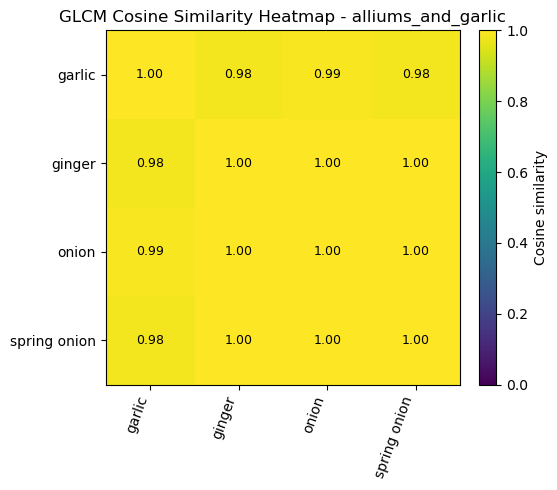

[alliums_and_garlic] valid pairs: 6/6 | pass >= 0.85: 6/6


,class_a,class_b,texture_similarity,samples_a,samples_b
0,onion,spring onion,0.999036,120,96
1,ginger,onion,0.998492,13,120
2,ginger,spring onion,0.996455,13,96
3,garlic,onion,0.988359,47,120
4,garlic,ginger,0.984130,47,13
5,garlic,spring onion,0.982740,47,96


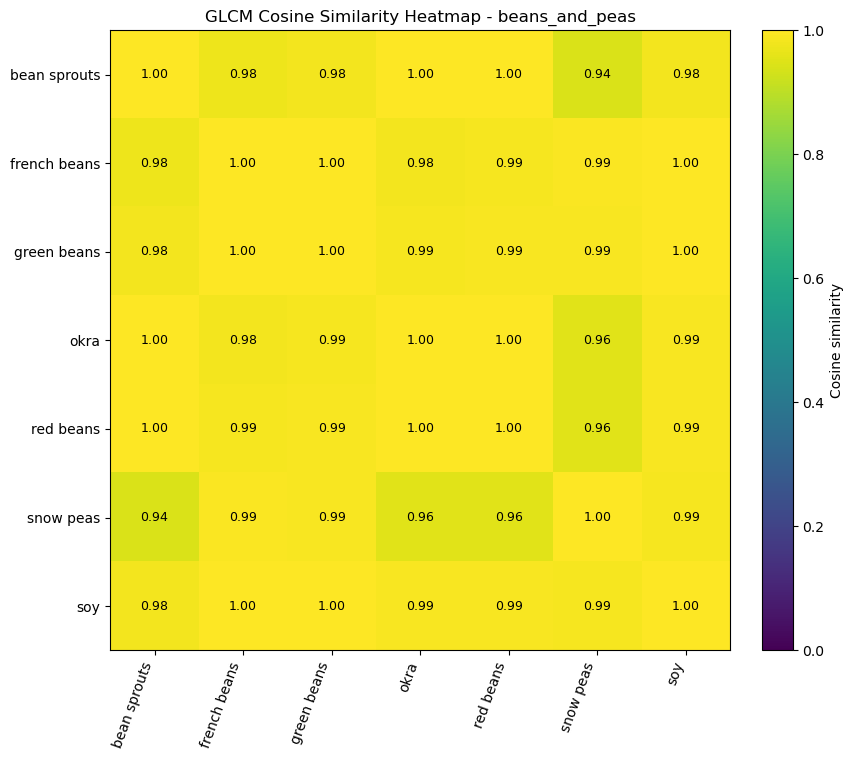

[beans_and_peas] valid pairs: 21/21 | pass >= 0.85: 21/21


,class_a,class_b,texture_similarity,samples_a,samples_b
0,okra,red beans,0.999810,3,11
1,green beans,soy,0.999808,120,24
2,french beans,green beans,0.999585,120,120
3,french beans,soy,0.999088,120,24
4,bean sprouts,okra,0.998970,14,3
5,bean sprouts,red beans,0.998861,14,11
6,french beans,snow peas,0.992492,120,32
7,red beans,soy,0.989605,11,24
8,green beans,red beans,0.988801,120,11
9,green beans,snow peas,0.988783,120,32


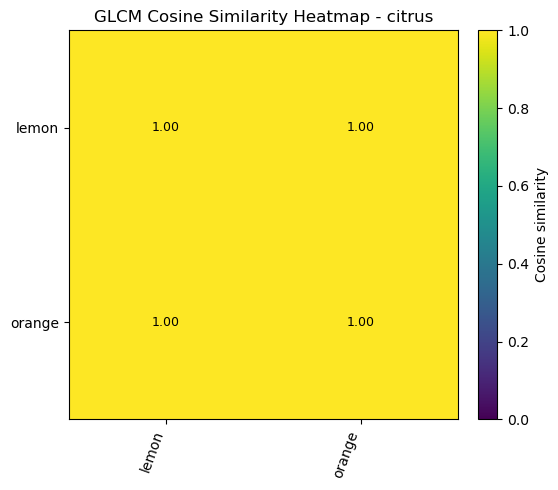

[citrus] valid pairs: 1/1 | pass >= 0.85: 1/1


,class_a,class_b,texture_similarity,samples_a,samples_b
0,lemon,orange,0.998866,120,120


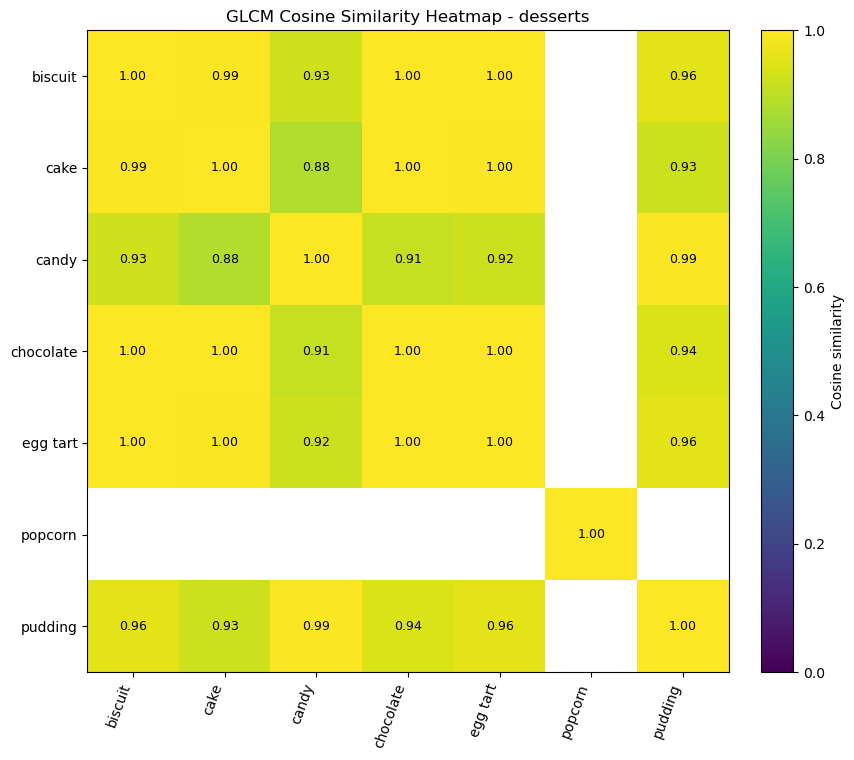

[desserts] valid pairs: 15/21 | pass >= 0.85: 15/15


,class_a,class_b,texture_similarity,samples_a,samples_b
0,biscuit,egg tart,0.999939,120,3
1,biscuit,chocolate,0.998233,120,37
2,chocolate,egg tart,0.998011,37,3
3,cake,chocolate,0.997204,120,37
4,cake,egg tart,0.995488,120,3
5,biscuit,cake,0.994944,120,120
6,candy,pudding,0.992598,6,4
7,biscuit,pudding,0.958487,120,4
8,egg tart,pudding,0.957083,3,4
9,chocolate,pudding,0.944342,37,4


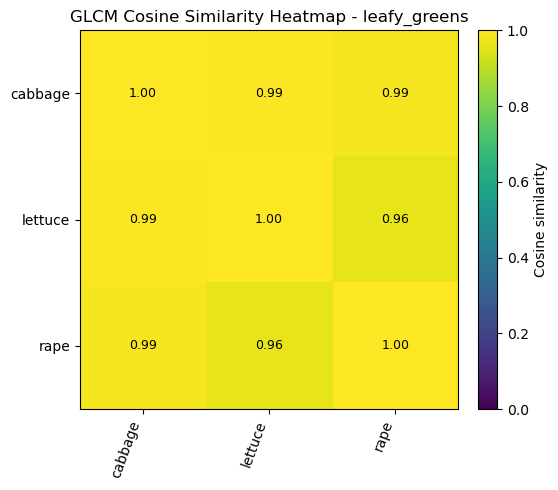

[leafy_greens] valid pairs: 3/3 | pass >= 0.85: 3/3


,class_a,class_b,texture_similarity,samples_a,samples_b
0,cabbage,lettuce,0.994643,81,120
1,cabbage,rape,0.985282,81,46
2,lettuce,rape,0.964551,120,46


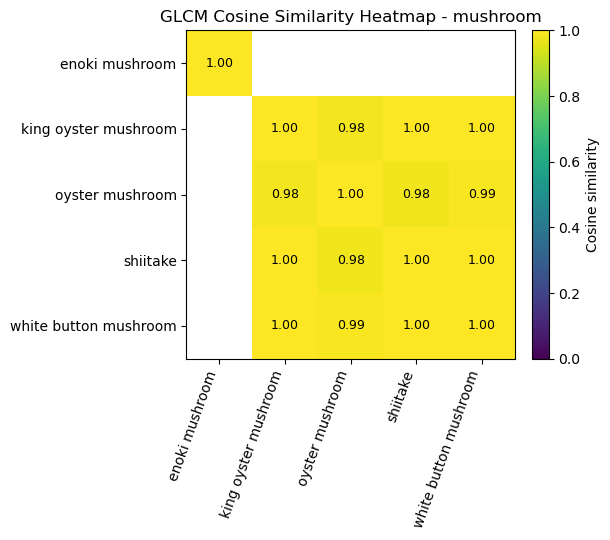

[mushroom] valid pairs: 6/10 | pass >= 0.85: 6/6


,class_a,class_b,texture_similarity,samples_a,samples_b
0,king oyster mushroom,shiitake,0.998378,4,50
1,king oyster mushroom,white button mushroom,0.997613,4,82
2,shiitake,white button mushroom,0.996832,50,82
3,oyster mushroom,white button mushroom,0.991948,3,82
4,king oyster mushroom,oyster mushroom,0.983314,4,3
5,oyster mushroom,shiitake,0.978737,3,50


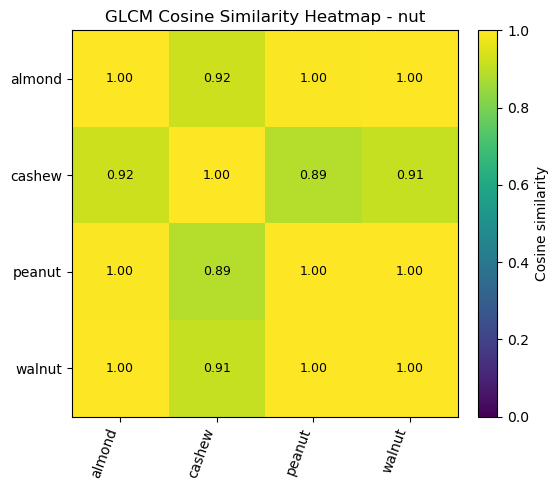

[nut] valid pairs: 6/6 | pass >= 0.85: 6/6


,class_a,class_b,texture_similarity,samples_a,samples_b
0,almond,walnut,0.999199,19,11
1,peanut,walnut,0.998618,4,11
2,almond,peanut,0.995939,19,4
3,almond,cashew,0.923657,19,2
4,cashew,walnut,0.912322,2,11
5,cashew,peanut,0.890393,2,4


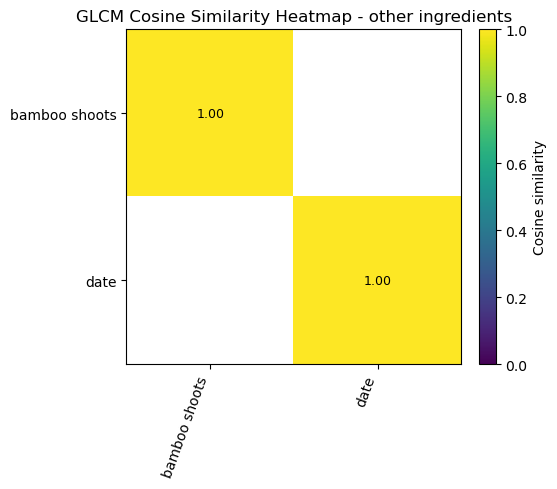

[other ingredients] valid pairs: 0/1 | pass >= 0.85: 0/0
[other ingredients] no finite similarity values to display.


In [11]:
# Visualize one heatmap per target_class (large class to be merged).
import matplotlib.pyplot as plt
import numpy as np

if "texture_similarity_df" not in globals() or len(texture_similarity_df) == 0:
    print("No texture similarity results yet. Run the GLCM texture gate cell first.")
else:
    raw_df = texture_similarity_df.copy()
    all_targets = sorted(raw_df["target_class"].dropna().unique().tolist())

    if len(all_targets) == 0:
        print("No target_class found in texture similarity table.")
    else:
        print(f"Number of merge groups to visualize: {len(all_targets)}")

        for target in all_targets:
            grp_all = raw_df[raw_df["target_class"] == target].copy()
            grp = grp_all[np.isfinite(grp_all["texture_similarity"])].copy()

            if len(grp_all) == 0:
                continue

            # Classes in this merge group.
            classes = sorted(set(grp_all["class_a"]).union(set(grp_all["class_b"])))
            if len(classes) < 2:
                print(f"[{target}] skipped: need at least 2 subclasses for a heatmap.")
                continue

            idx = {c: i for i, c in enumerate(classes)}
            sim_mat = np.full((len(classes), len(classes)), np.nan, dtype=float)
            np.fill_diagonal(sim_mat, 1.0)

            for _, r in grp.iterrows():
                i = idx[r["class_a"]]
                j = idx[r["class_b"]]
                s = float(r["texture_similarity"])
                sim_mat[i, j] = s
                sim_mat[j, i] = s

            fig_w = max(6, 1.3 * len(classes))
            fig_h = max(5, 1.1 * len(classes))
            fig, ax = plt.subplots(figsize=(fig_w, fig_h))

            im = ax.imshow(sim_mat, vmin=0.0, vmax=1.0, cmap="viridis")
            ax.set_title(f"GLCM Cosine Similarity Heatmap - {target}")
            ax.set_xticks(range(len(classes)))
            ax.set_xticklabels(classes, rotation=70, ha="right")
            ax.set_yticks(range(len(classes)))
            ax.set_yticklabels(classes)
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label("Cosine similarity")

            # Annotate values and mark below-threshold pairs.
            for i in range(len(classes)):
                for j in range(len(classes)):
                    val = sim_mat[i, j]
                    if np.isnan(val):
                        continue
                    txt_color = "white" if val < 0.55 else "black"
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=txt_color, fontsize=9)

            for _, r in grp.iterrows():
                if float(r["texture_similarity"]) < GLCM_COSINE_THRESHOLD:
                    i = idx[r["class_a"]]
                    j = idx[r["class_b"]]
                    ax.plot(j, i, marker="x", color="red", markersize=8, mew=2)
                    ax.plot(i, j, marker="x", color="red", markersize=8, mew=2)

            plt.tight_layout()
            plt.show()

            n_total = int(len(grp_all))
            n_valid = int(len(grp))
            n_pass = int((grp["texture_similarity"] >= GLCM_COSINE_THRESHOLD).sum()) if n_valid else 0
            print(f"[{target}] valid pairs: {n_valid}/{n_total} | pass >= {GLCM_COSINE_THRESHOLD}: {n_pass}/{n_valid if n_valid else 0}")

            if n_valid:
                display(
                    grp.sort_values("texture_similarity", ascending=False)[
                        ["class_a", "class_b", "texture_similarity", "samples_a", "samples_b"]
                    ].reset_index(drop=True)
                )
            else:
                print(f"[{target}] no finite similarity values to display.")

In [6]:
# Build rebalance plan from thresholds + merge map + overrides
base_merge_map = texture_validated_merge_map if "texture_validated_merge_map" in globals() else MERGE_MAP
clean_merge_map = {
    str(k).strip(): str(v).strip()
    for k, v in base_merge_map.items()
    if str(k).strip() and str(v).strip()
}

if "texture_group_df" in globals() and len(texture_group_df) > 0:
    approved_groups = int((texture_group_df["decision"] == "approved").sum())
    print(f"Texture-gated merge groups approved: {approved_groups}/{len(texture_group_df)}")

known_classes = set(class_stats_df["class_name"].tolist())
unknown_merge_keys = sorted(set(clean_merge_map.keys()) - known_classes)
if unknown_merge_keys:
    print("Warning: some MERGE_MAP keys not found in observed classes:")
    print(unknown_merge_keys[:20])

source_to_target = {c: clean_merge_map.get(c, c) for c in known_classes}
target_to_sources = defaultdict(list)
for src, tgt in source_to_target.items():
    target_to_sources[tgt].append(src)

target_rows = []
for tgt, src_list in target_to_sources.items():
    objects = int(class_stats_df[class_stats_df["class_name"].isin(src_list)]["objects"].sum())
    images = int(class_stats_df[class_stats_df["class_name"].isin(src_list)]["images"].sum())
    target_rows.append({
        "target_class": tgt,
        "n_source_classes": len(src_list),
        "objects": objects,
        "images": images,
        "source_classes": ", ".join(sorted(src_list)),
    })

target_stats_df = pd.DataFrame(target_rows).sort_values(["objects", "images"], ascending=False).reset_index(drop=True)

kept_targets = set(target_stats_df.loc[
    (target_stats_df["images"] >= MIN_IMAGES_PER_CLASS)
    & (target_stats_df["objects"] >= MIN_OBJECTS_PER_CLASS),
    "target_class",
].tolist())

kept_targets |= {clean_merge_map.get(c, c) for c in FORCE_KEEP_CLASSES}
kept_targets -= {clean_merge_map.get(c, c) for c in FORCE_DROP_CLASSES}

plan_rows = []
for src in sorted(known_classes):
    src_obj = int(class_stats_df.loc[class_stats_df["class_name"] == src, "objects"].sum())
    src_img = int(class_stats_df.loc[class_stats_df["class_name"] == src, "images"].sum())
    tgt = source_to_target[src]
    tgt_obj = int(target_stats_df.loc[target_stats_df["target_class"] == tgt, "objects"].sum())
    tgt_img = int(target_stats_df.loc[target_stats_df["target_class"] == tgt, "images"].sum())
    keep = tgt in kept_targets
    action = "merge_keep" if (src != tgt and keep) else "keep" if keep else "drop"
    plan_rows.append({
        "source_class": src,
        "target_class": tgt,
        "source_objects": src_obj,
        "source_images": src_img,
        "target_objects": tgt_obj,
        "target_images": tgt_img,
        "keep": keep,
        "action": action,
    })

plan_df = pd.DataFrame(plan_rows).sort_values(["keep", "target_objects", "source_objects"], ascending=[False, False, False]).reset_index(drop=True)

new_class_titles = sorted(kept_targets)
new_class_id_map = {name: i + 1 for i, name in enumerate(new_class_titles)}

print(f"Target classes after merge/filter: {len(new_class_titles)}")
print(f"Dropped source classes: {(~plan_df['keep']).sum()}")
display(target_stats_df.head(30))
display(plan_df.head(50))

Texture-gated merge groups approved: 5/8
Target classes after merge/filter: 87
Dropped source classes: 0


,target_class,n_source_classes,objects,images,source_classes
0,bread,1,1259,1259,bread
1,carrot,1,1172,1172,carrot
2,chicken duck,1,1124,1124,chicken duck
3,sauce,1,1051,1051,sauce
4,tomato,1,1034,1034,tomato
5,potato,1,1001,1001,potato
6,steak,1,983,983,steak
7,broccoli,1,935,935,broccoli
8,ice cream,1,790,790,ice cream
9,cilantro mint,1,769,769,cilantro mint


,source_class,target_class,source_objects,source_images,target_objects,target_images,keep,action
0,bread,bread,1259,1259,1259,1259,True,keep
1,carrot,carrot,1172,1172,1172,1172,True,keep
2,chicken duck,chicken duck,1124,1124,1124,1124,True,keep
3,sauce,sauce,1051,1051,1051,1051,True,keep
4,tomato,tomato,1034,1034,1034,1034,True,keep
5,potato,potato,1001,1001,1001,1001,True,keep
6,steak,steak,983,983,983,983,True,keep
7,broccoli,broccoli,935,935,935,935,True,keep
8,ice cream,ice cream,790,790,790,790,True,keep
9,cilantro mint,cilantro mint,769,769,769,769,True,keep


In [7]:
# Export filtered + merged dataset (with bad-image filtering + train-format-safe meta.json)
from PIL import Image, UnidentifiedImageError

if len(new_class_titles) == 0:
    raise RuntimeError("No classes kept. Relax thresholds or adjust MERGE_MAP/FORCE_KEEP_CLASSES.")

if EXECUTE_EXPORT:
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

def is_valid_image_file(path: Path) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()  # Fast integrity check
        # Re-open and load to ensure decoding actually works.
        with Image.open(path) as img:
            img.load()
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False

export_stats = []

for split in SPLITS:
    in_img_dir = DATASET_ROOT / split / "img"
    in_ann_dir = DATASET_ROOT / split / "ann"

    out_img_dir = OUTPUT_ROOT / split / "img"
    out_ann_dir = OUTPUT_ROOT / split / "ann"
    if EXECUTE_EXPORT:
        out_img_dir.mkdir(parents=True, exist_ok=True)
        out_ann_dir.mkdir(parents=True, exist_ok=True)

    image_files = sorted([p for p in in_img_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]) if in_img_dir.exists() else []
    if MAX_FILES_PER_SPLIT is not None:
        image_files = image_files[:MAX_FILES_PER_SPLIT]

    input_images = 0
    output_images = 0
    missing_ann = 0
    bad_ann = 0
    bad_image = 0
    dropped_empty = 0
    input_objects = 0
    output_objects = 0

    for img_path in tqdm(image_files, desc=f"Export {split}"):
        input_images += 1

        if not is_valid_image_file(img_path):
            bad_image += 1
            img_path.unlink()  # Delete the bad image file
            continue

        ann_path = in_ann_dir / f"{img_path.name}.json"

        if not ann_path.exists():
            missing_ann += 1
            if not COPY_ONLY_IMAGES_WITH_ANNOTATION and EXECUTE_EXPORT:
                shutil.copy2(img_path, out_img_dir / img_path.name)
                output_images += 1
            continue

        try:
            with open(ann_path, "r", encoding="utf-8") as f:
                ann = json.load(f)
        except Exception:
            bad_ann += 1
            continue

        objs = ann.get("objects", [])
        if not isinstance(objs, list):
            bad_ann += 1
            continue

        input_objects += len(objs)

        new_objects = []
        for obj in objs:
            if not isinstance(obj, dict):
                continue
            src = extract_class_name(obj)
            tgt = source_to_target.get(src, src)
            if tgt not in new_class_id_map:
                continue

            obj_new = dict(obj)
            obj_new["classTitle"] = tgt
            obj_new["classId"] = int(new_class_id_map[tgt])
            new_objects.append(obj_new)

        output_objects += len(new_objects)

        if DROP_IMAGES_WITH_NO_OBJECTS and len(new_objects) == 0:
            dropped_empty += 1
            continue

        if EXECUTE_EXPORT:
            ann_new = dict(ann)
            ann_new["objects"] = new_objects

            shutil.copy2(img_path, out_img_dir / img_path.name)
            with open(out_ann_dir / f"{img_path.name}.json", "w", encoding="utf-8") as f:
                json.dump(ann_new, f, ensure_ascii=False)

        output_images += 1

    export_stats.append({
        "split": split,
        "input_images": input_images,
        "output_images": output_images,
        "missing_annotation": missing_ann,
        "bad_annotation": bad_ann,
        "bad_image": bad_image,
        "dropped_empty_images": dropped_empty,
        "input_objects": input_objects,
        "output_objects": output_objects,
    })

export_df = pd.DataFrame(export_stats)
display(export_df)

if EXECUTE_EXPORT:
    # Build train-format-safe meta.json that preserves the original project schema.
    new_meta_classes = []
    for class_name in new_class_titles:
        src_candidates = sorted(target_to_sources.get(class_name, [class_name]))
        base = None
        for src in src_candidates:
            if src in title_to_meta:
                base = dict(title_to_meta[src])
                break

        if base is None:
            base = {
                "title": class_name,
                "shape": "bitmap",
                "color": "#FFFFFF",
                "geometry_config": {},
                "id": int(new_class_id_map[class_name]),
                "hotkey": "",
            }

        base["title"] = class_name
        base["id"] = int(new_class_id_map[class_name])
        base.setdefault("shape", "bitmap")
        base.setdefault("color", "#FFFFFF")
        base.setdefault("geometry_config", {})
        base.setdefault("hotkey", "")
        new_meta_classes.append(base)

    # Keep the full project structure from original meta and only remap classes.
    new_meta = dict(meta)
    new_meta["classes"] = sorted(new_meta_classes, key=lambda x: int(x["id"]))
    new_meta.setdefault("tags", meta.get("tags", []))
    new_meta.setdefault("projectType", meta.get("projectType", "images"))
    new_meta.setdefault("projectSettings", meta.get("projectSettings", {}))

    with open(OUTPUT_ROOT / "meta.json", "w", encoding="utf-8") as f:
        json.dump(new_meta, f, indent=2, ensure_ascii=False)

    # Save mapping and plan for reproducibility.
    plan_out = OUTPUT_ROOT / "class_rebalance_plan.csv"
    plan_df.to_csv(plan_out, index=False)

    merged_rows = []
    for src in sorted(source_to_target):
        tgt = source_to_target[src]
        src_meta = title_to_meta.get(src, {})
        merged_rows.append({
            "source_class": src,
            "source_class_id": src_meta.get("id", None),
            "target_class": tgt,
            "kept": tgt in new_class_id_map,
            "new_class_id": new_class_id_map.get(tgt, None),
        })

    mapping_df = pd.DataFrame(merged_rows)
    mapping_df.to_csv(OUTPUT_ROOT / "class_mapping.csv", index=False)

    print(f"Export completed: {OUTPUT_ROOT.resolve()}")
    print(f"Saved: {plan_out.resolve()}")
    print(f"Saved: {(OUTPUT_ROOT / 'class_mapping.csv').resolve()}")
    print(f"Saved: {(OUTPUT_ROOT / 'meta.json').resolve()}")
else:
    print("Dry run mode: set EXECUTE_EXPORT = True to write output files.")

Export train:   0%|          | 0/3981 [00:00<?, ?it/s]

Export test:   0%|          | 0/2135 [00:00<?, ?it/s]

,split,input_images,output_images,missing_annotation,bad_annotation,bad_image,dropped_empty_images,input_objects,output_objects
0,train,3981,3981,0,0,0,0,14953,14953
1,test,2135,2135,0,0,0,0,7697,7697


Export completed: D:\CODE\PROJECT-CV\test\foodseg103_rebalanced
Saved: D:\CODE\PROJECT-CV\test\foodseg103_rebalanced\class_rebalance_plan.csv
Saved: D:\CODE\PROJECT-CV\test\foodseg103_rebalanced\class_mapping.csv
Saved: D:\CODE\PROJECT-CV\test\foodseg103_rebalanced\meta.json


In [8]:
# Quick sanity checks after export (meta/class mapping + file integrity)
if EXECUTE_EXPORT:
    out_meta = OUTPUT_ROOT / "meta.json"
    print(f"meta.json exists: {out_meta.exists()}")

    with open(out_meta, "r", encoding="utf-8") as f:
        out_meta_json = json.load(f)

    required_top_keys = ["classes", "tags", "projectType", "projectSettings"]
    missing_top_keys = [k for k in required_top_keys if k not in out_meta_json]
    print(f"Missing top-level meta keys: {missing_top_keys}")

    out_classes = out_meta_json.get("classes", [])
    out_id_to_title = {int(c["id"]): str(c["title"]).strip() for c in out_classes if "id" in c and "title" in c}
    duplicate_ids = len(out_id_to_title) != len(out_classes)
    print(f"Output classes: {len(out_classes)} | duplicate class ids: {duplicate_ids}")

    for split in SPLITS:
        out_img = OUTPUT_ROOT / split / "img"
        out_ann = OUTPUT_ROOT / split / "ann"
        img_files = sorted([p for p in out_img.iterdir() if p.suffix.lower() in IMAGE_EXTS]) if out_img.exists() else []
        ann_files = sorted(list(out_ann.glob("*.json"))) if out_ann.exists() else []
        print(f"[{split}] images={len(img_files)}, annotations={len(ann_files)}")

        bad_ann_json = 0
        bad_ref = 0
        for ann_path in ann_files:
            try:
                with open(ann_path, "r", encoding="utf-8") as f:
                    ann = json.load(f)
            except Exception:
                bad_ann_json += 1
                continue

            objs = ann.get("objects", [])
            if not isinstance(objs, list):
                bad_ann_json += 1
                continue

            for obj in objs:
                cls_title = str(obj.get("classTitle", "")).strip()
                cls_id = obj.get("classId", None)
                try:
                    cls_id = int(cls_id)
                except (TypeError, ValueError):
                    bad_ref += 1
                    continue

                if cls_id not in out_id_to_title:
                    bad_ref += 1
                    continue

                if out_id_to_title[cls_id] != cls_title:
                    bad_ref += 1

        print(f"[{split}] bad annotation json={bad_ann_json}, bad class references={bad_ref}")

    print("Sanity check complete.")
else:
    print("No files were exported yet. Enable EXECUTE_EXPORT and run export cell.")

meta.json exists: True
Missing top-level meta keys: []
Output classes: 87 | duplicate class ids: False
[train] images=3981, annotations=3981
[train] bad annotation json=0, bad class references=0
[test] images=2135, annotations=2135
[test] bad annotation json=0, bad class references=0
Sanity check complete.
